In [1]:
# from google.colab import files

# files.upload()

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [13]:
!pip install -q kaggle "tensorflow>=2.17.0" gradio matplotlib

In [12]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [5]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# # If dataset not downloaded yet, download & unzip (comment out if already present)
# import os
# if not os.path.exists("/content/new-plant-diseases-dataset"):
#     !kaggle datasets download -d vipooooool/new-plant-diseases-dataset -p /content
#     !unzip -q /content/new-plant-diseases-dataset.zip -d /content/new-plant-diseases-dataset

# # Confirm dataset presence (small print)
# !ls -lah /content/new-plant-diseases-dataset | sed -n '1,200p'

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Path to dataset files: /kaggle/input/new-plant-diseases-dataset


**Configure the dataset path for training and validation**

In [16]:
img_size  = (224, 224)
batch_size = 32
epochs = 5

n_last_layers = 10
seed =1337

#dataset paths for train and validation

train_dir = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
validation_dir = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

for paths in [train_dir, validation_dir]:
    if  not os.path.exists(paths):
        print(f"Path not found : {paths}")

print("train_dir : ",train_dir)
print("validation_dir : ",validation_dir)

train_dir :  /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
validation_dir :  /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


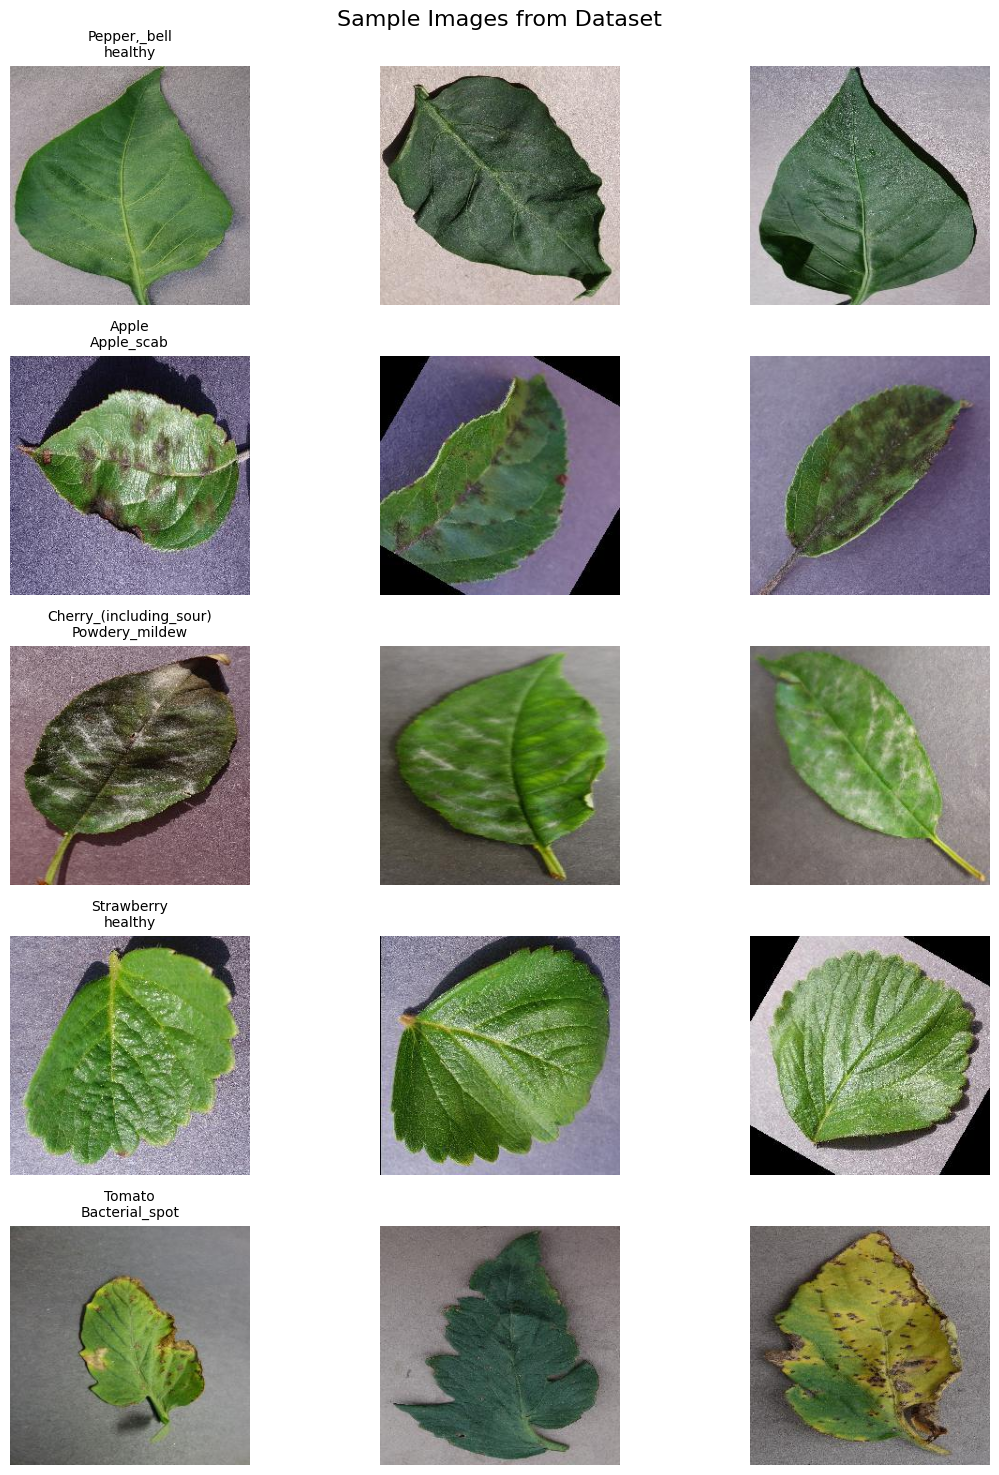

In [17]:
import random
from IPython.display import Image, display

# Function to display random samples from each class
def show_sample_images(base_path, num_classes=5, images_per_class=3):
    """Display random sample images from the dataset"""
    class_names = os.listdir(base_path)
    random_classes = random.sample(class_names, min(num_classes, len(class_names)))

    fig, axes = plt.subplots(num_classes, images_per_class,
                             figsize=(12, 3*num_classes))
    fig.suptitle('Sample Images from Dataset', fontsize=16)

    for i, class_name in enumerate(random_classes):
        class_path = os.path.join(base_path, class_name)
        images = os.listdir(class_path)
        random_images = random.sample(images, min(images_per_class, len(images)))

        for j, img_name in enumerate(random_images):
            img_path = os.path.join(class_path, img_name)
            img = plt.imread(img_path)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(class_name.replace('___', '\n'), fontsize=10)

    plt.tight_layout()
    plt.show()

# Call the function to display sample images from the training directory
show_sample_images(train_dir)

**Datset Statistics**



In [18]:
# Count images in each split
def count_images(directory):
    """Count total images and images per class"""
    total_images = 0
    class_counts = {}

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            class_counts[class_name] = num_images
            total_images += num_images

    return total_images, class_counts

# Get statistics
train_total, train_counts = count_images(train_dir)
valid_total, valid_counts = count_images(validation_dir)

print(f"Training images: {train_total}")
print(f"Validation images: {valid_total}")
print(f"Number of classes: {len(train_counts)}")
print(f"\nClass distribution (first 10):")
for i, (class_name, count) in enumerate(list(train_counts.items())[:10]):
    print(f"  {class_name}: {count} images")

Training images: 70295
Validation images: 17572
Number of classes: 38

Class distribution (first 10):
  Tomato___Late_blight: 1851 images
  Tomato___healthy: 1926 images
  Grape___healthy: 1692 images
  Orange___Haunglongbing_(Citrus_greening): 2010 images
  Soybean___healthy: 2022 images
  Squash___Powdery_mildew: 1736 images
  Potato___healthy: 1824 images
  Corn_(maize)___Northern_Leaf_Blight: 1908 images
  Tomato___Early_blight: 1920 images
  Tomato___Septoria_leaf_spot: 1745 images


**Data Preprocessing and Augmentation**

In [19]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Training data generator with light augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='reflect'
)

# Validation data generator (no augmentation)
valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Create data generators
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=seed
)

valid_gen = valid_datagen.flow_from_directory(
    validation_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


**Epic 2: Model Building**

**Load Pre-trained MobileNetV2**

In [20]:
num_classes = train_gen.num_classes

# Load the pre-trained MobileNetV2 model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=img_size + (3,), # Ensure input_shape matches img_size and 3 channels
    include_top=False,
    weights='imagenet'
)

# Display the base model summary
print(base_model.summary())

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

None


**Configure Transfer Learning Strategy**

In [21]:
# Freeze all layers initially
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last N layers for fine-tuning
if n_last_layers > 0:
    for layer in base_model.layers[-n_last_layers:]:
        layer.trainable = True

# Count trainable parameters
trainable_count = sum([tf.size(w).numpy() for w in base_model.trainable_weights])
non_trainable_count = sum([tf.size(w).numpy() for w in base_model.non_trainable_weights])

print(f"Trainable parameters: {trainable_count:,}")
print(f"Non-trainable parameters: {non_trainable_count:,}")
print(f"Unfrozen last {n_last_layers} layers for fine-tuning")

Trainable parameters: 732,480
Non-trainable parameters: 1,525,504
Unfrozen last 10 layers for fine-tuning


In [22]:
# Build the complete model
inputs = keras.Input(shape=img_size + (3,))
x = base_model(inputs, training=False)  # Frozen BatchNorm layers
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs, name="mobilenetv2_plant_disease_classifier")

# Display model summary
model.summary()

Model: "mobilenetv2_plant_disease_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 1,070,182 (4.08 MB)

 Non-trainable params: 1,525,504 (5.82 MB)

**Compile the Model**

In [23]:
# Compile model with appropriate settings
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4), # Low learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"Optimizer: Adam (lr=1e-4)")
print(f"Loss function: Categorical Crossentropy")
print(f"Metrics: Accuracy")

Model compiled successfully!
Optimizer: Adam (lr=1e-4)
Loss function: Categorical Crossentropy
Metrics: Accuracy


**Setup Training Callbacks**

In [24]:
# Define training callbacks
callbacks = [
    # Save best model based on validation accuracy
    keras.callbacks.ModelCheckpoint(
        "/content/mobilenetv2_best.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # Reduce learning rate when validation loss plateaus
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),

    # Stop training if no improvement
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
]

print("Callbacks configured:")
print("  1. ModelCheckpoint - Saves best model")
print("  2. ReduceLROnPlateau - Adjusts learning rate")
print("  3. EarlyStopping - Prevents overfitting")

Callbacks configured:
  1. ModelCheckpoint - Saves best model
  2. ReduceLROnPlateau - Adjusts learning rate
  3. EarlyStopping - Prevents overfitting


**Train the Model**

In [26]:
history = model.fit(
    train_gen,
    epochs=epochs,
    validation_data=valid_gen,
    callbacks=callbacks,
    steps_per_epoch=100,
    validation_steps=50
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2898 - loss: 2.8024

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.13438, saving model to /content/mobilenetv2_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.2906 - loss: 2.7990 - val_accuracy: 0.1344 - val_loss: 2.8651 - learning_rate: 1.0000e-04
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5751 - loss: 1.6021
Epoch 2: val_accuracy improved from 0.13438 to 0.38438, saving model to /content/mobilenetv2_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 259s 3s/step - accuracy: 0.5755 - loss: 1.6003 - val_accuracy: 0.3844 - val_loss: 1.8799 - learning_rate: 1.0000e-04
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6878 - loss: 1.0876
Epoch 3: val_accuracy improved from 0.38438 to 0.48000, saving model to /content/mobilenetv2_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 266s 3s/step - accuracy: 0.6880 - loss: 1.0867 - val_accuracy: 0.4800 - val_loss: 1.6727 - learning_rate: 1.0000e-04
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7700 - loss: 0.8288


**Visualize Training History**

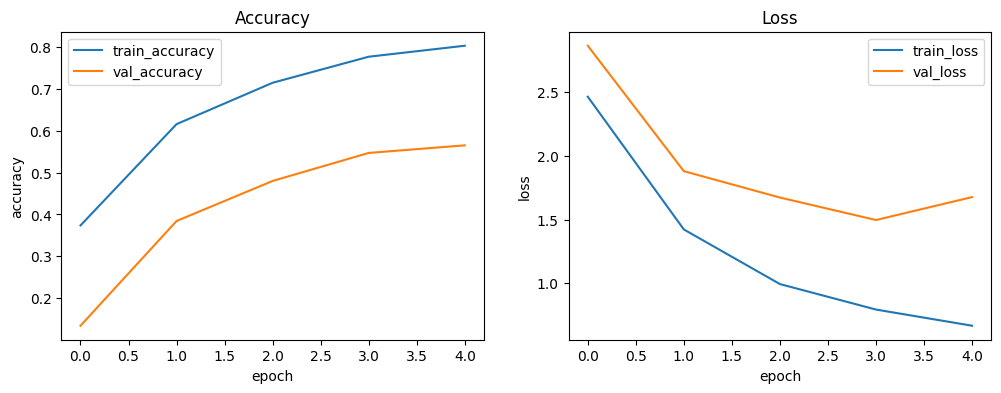

In [27]:

# -------------------- Plot training curves --------------------
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history.get('accuracy', []), label='train_accuracy')
plt.plot(history.history.get('val_accuracy', []), label='val_accuracy')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(); plt.title('Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history.get('loss', []), label='train_loss')
plt.plot(history.history.get('val_loss', []), label='val_loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('Loss')

plt.show()

**Model Evaluation and Testing**

**Evaluate Model Performance**

In [28]:
print("Evaluating model performance on the validation set...")
loss, accuracy = model.evaluate(valid_gen)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

Evaluating model performance on the validation set...
550/550 ━━━━━━━━━━━━━━━━━━━━ 709s 1s/step - accuracy: 0.6712 - loss: 1.0996
Validation Loss: 1.2221
Validation Accuracy: 0.6544


**Save the Final Model**

In [29]:
# Save the final model
model.save('/content/final_plant_disease_classifier.keras')
print("Final model saved as /content/final_plant_disease_classifier.keras")

Final model saved as /content/final_plant_disease_classifier.keras
